In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

### W from Copernicus

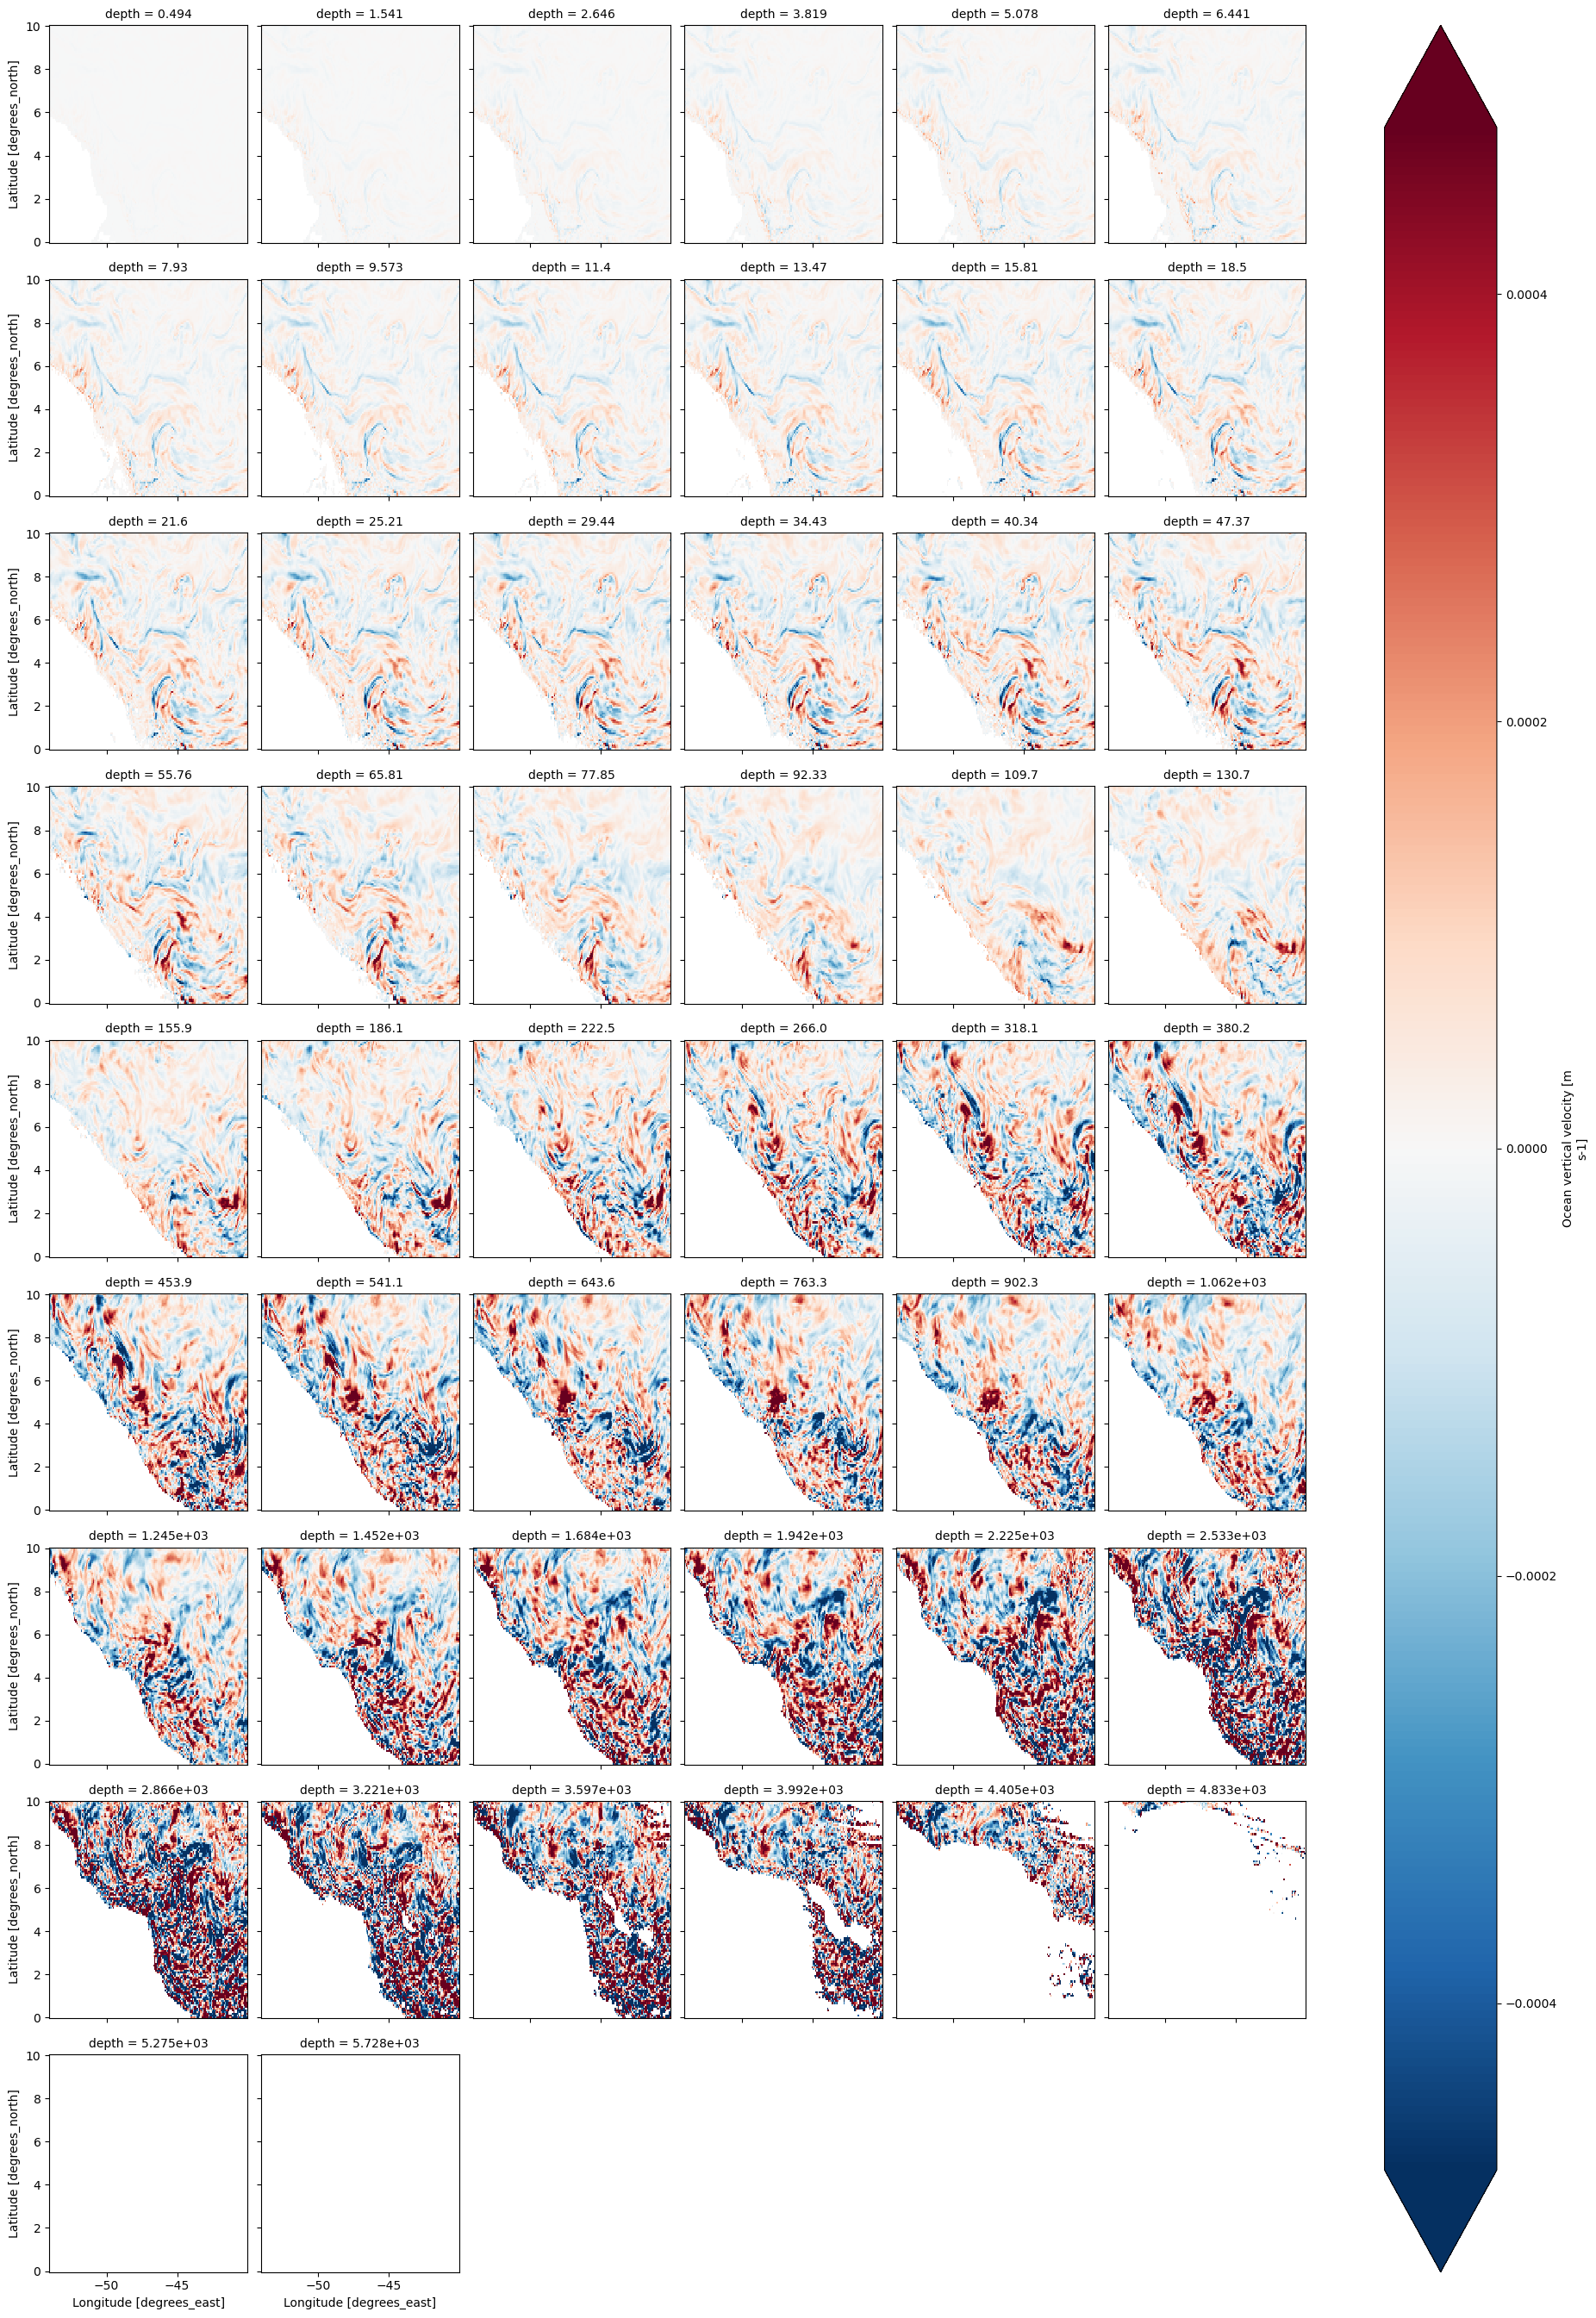

In [2]:
ds_w = xr.open_dataset(r'../data/cmems_mod_glo_phy-wcur_anfc_0.083deg_P1D-m_1750790131083.nc')
ds_w.isel(time=0).wo.plot(x='longitude',y='latitude',col='depth',col_wrap=6, robust=True)

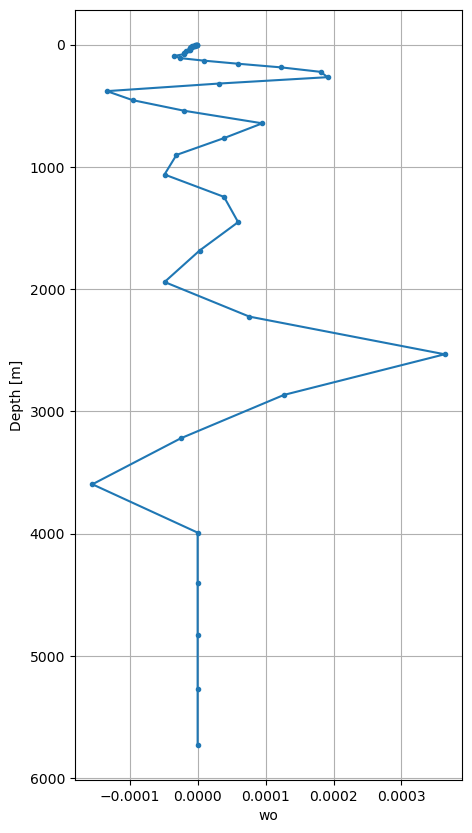

In [3]:
# lat_min, lat_max = 8, 10
# lon_min, lon_max = -49, -47
ds_w.wo.fillna(0).isel(latitude=slice(8,10),longitude=slice(-49,-47)).mean(dim=('longitude','latitude','time'),skipna=True).plot(y='depth',figsize=(5,10),marker='.')
plt.gca().invert_yaxis()
plt.grid()

### W calculated from volume fluxes

In [4]:
ds = xr.open_dataset(r'../data/cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m_1750791592444.nc')

## Mask calculation
_lat = ds.latitude
_lon = ds.longitude
_zt = ds.depth

ds = ds.rename({"depth": "k", "latitude":"j", "longitude":"i"})
ds = ds.assign_coords(
    k=np.arange(ds.sizes["k"]),
    j=np.arange(ds.sizes["j"]),
    i=np.arange(ds.sizes["i"]),
    depth_t=("k", _zt.data),
    latitude_f = ("j", _lat.data),
    longitude_f = ("i", _lon.data),
)

ds = ds.rename({"uo":"uf", "vo":"vf"})

## Calculate F and T mask
ds = ds.assign(fmask = ds.uf.isel(time=0,drop=True).notnull())

ds = ds.assign(
    tmask=(
        ds.fmask.shift(i=0,j=0)
        | ds.fmask.shift(i=-1,j=-1).fillna(False)
        | ds.fmask.shift(i=0, j=-1).fillna(False)
        | ds.fmask.shift(i=-1,j=-1).fillna(False)
    ).astype(bool)
)

## Calculate U and V faces
ds = ds.assign(
    u=(ds.uf.fillna(0) + ds.uf.shift(j=-1).fillna(0)) /2,
    v=(ds.vf.fillna(0) + ds.vf.shift(i=-1).fillna(0)) /2,
)

## Calculate Zt
zt = ds.depth_t.data
zw = [zt[0]*2]


for k in range(1,50):
    zw.append((zt[k] - zw[k-1])*2 + zw[k-1])

ds = ds.assign_coords(depth_w = ("k",zw))

ds = ds.assign_coords(
    longitude_u = ds.longitude_f,
    latitude_v =  ds.latitude_f,
    
    latitude_u = ds.latitude_f + 1/12/2, 
    longitude_v = ds.longitude_f + 1/12/2,
    
    latitude_t = ds.latitude_f + 1/12/2, 
    longitude_t = ds.longitude_f + 1/12/2,
)

R = 6371e3 

ds = ds.assign_coords(
    dz_t = ds.depth_w - ds.depth_w.shift(k=1).fillna(0), 
    dx_t = np.deg2rad(1/12) * R * np.cos(np.deg2rad(ds.latitude_t)),
    dy_t = np.deg2rad(1/12) * R ,
    
)

## we find the total volume flux - m3
F_uv_vol = (
    ds.u * ds.dy_t * ds.dz_t - ds.u.shift(i=-1)* ds.dy_t * ds.dz_t 
    + ds.v * ds.dx_t * ds.dz_t - ds.v.shift(j=-1) * ds.dx_t * ds.dz_t
).fillna(0)

#we divide the total flux by the volume (dx*dy*dz) - 1/s
dw_by_dz = -F_uv_vol/ds.dx_t/ds.dy_t/ds.dz_t

w = (dw_by_dz.fillna(0) * ds.dz_t.fillna(0)).cumsum('k').fillna(0).where(ds.tmask==1)

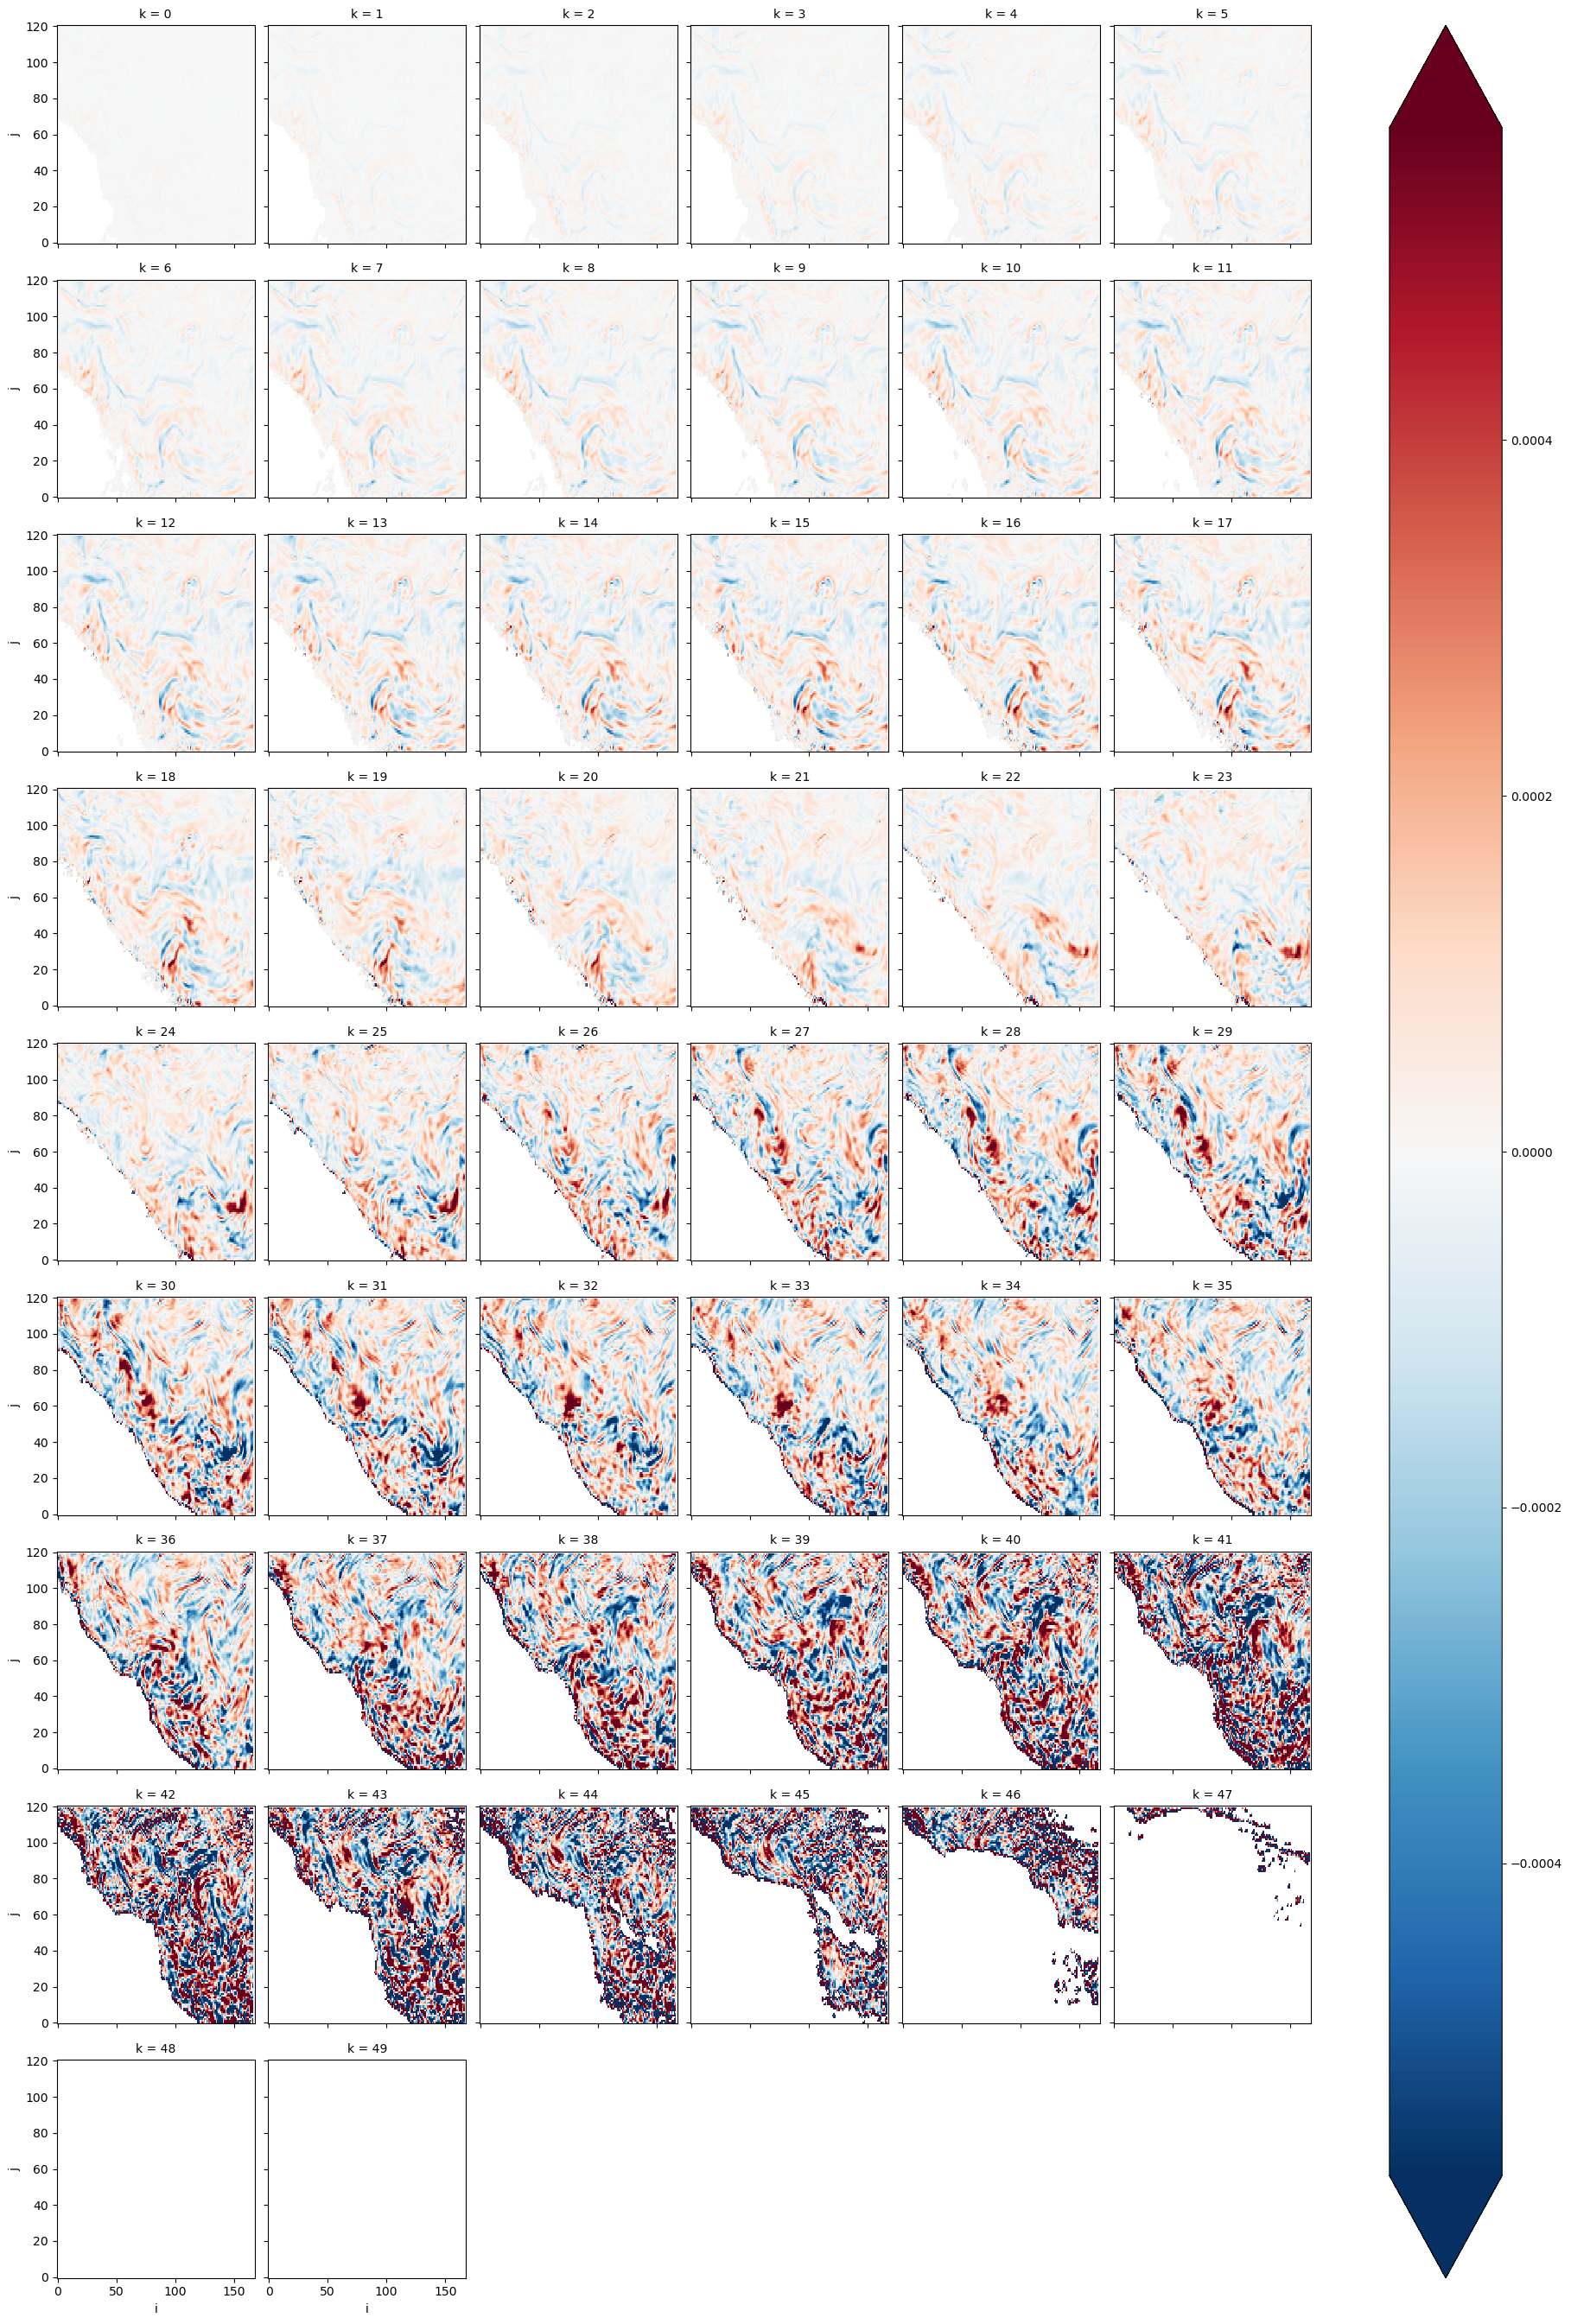

In [5]:
w.isel(time=0).plot(x='i',y='j',col='k',col_wrap=6, robust=True)

In [6]:
w_bottom=w.isel(k=ds.tmask.sum('k')-1)

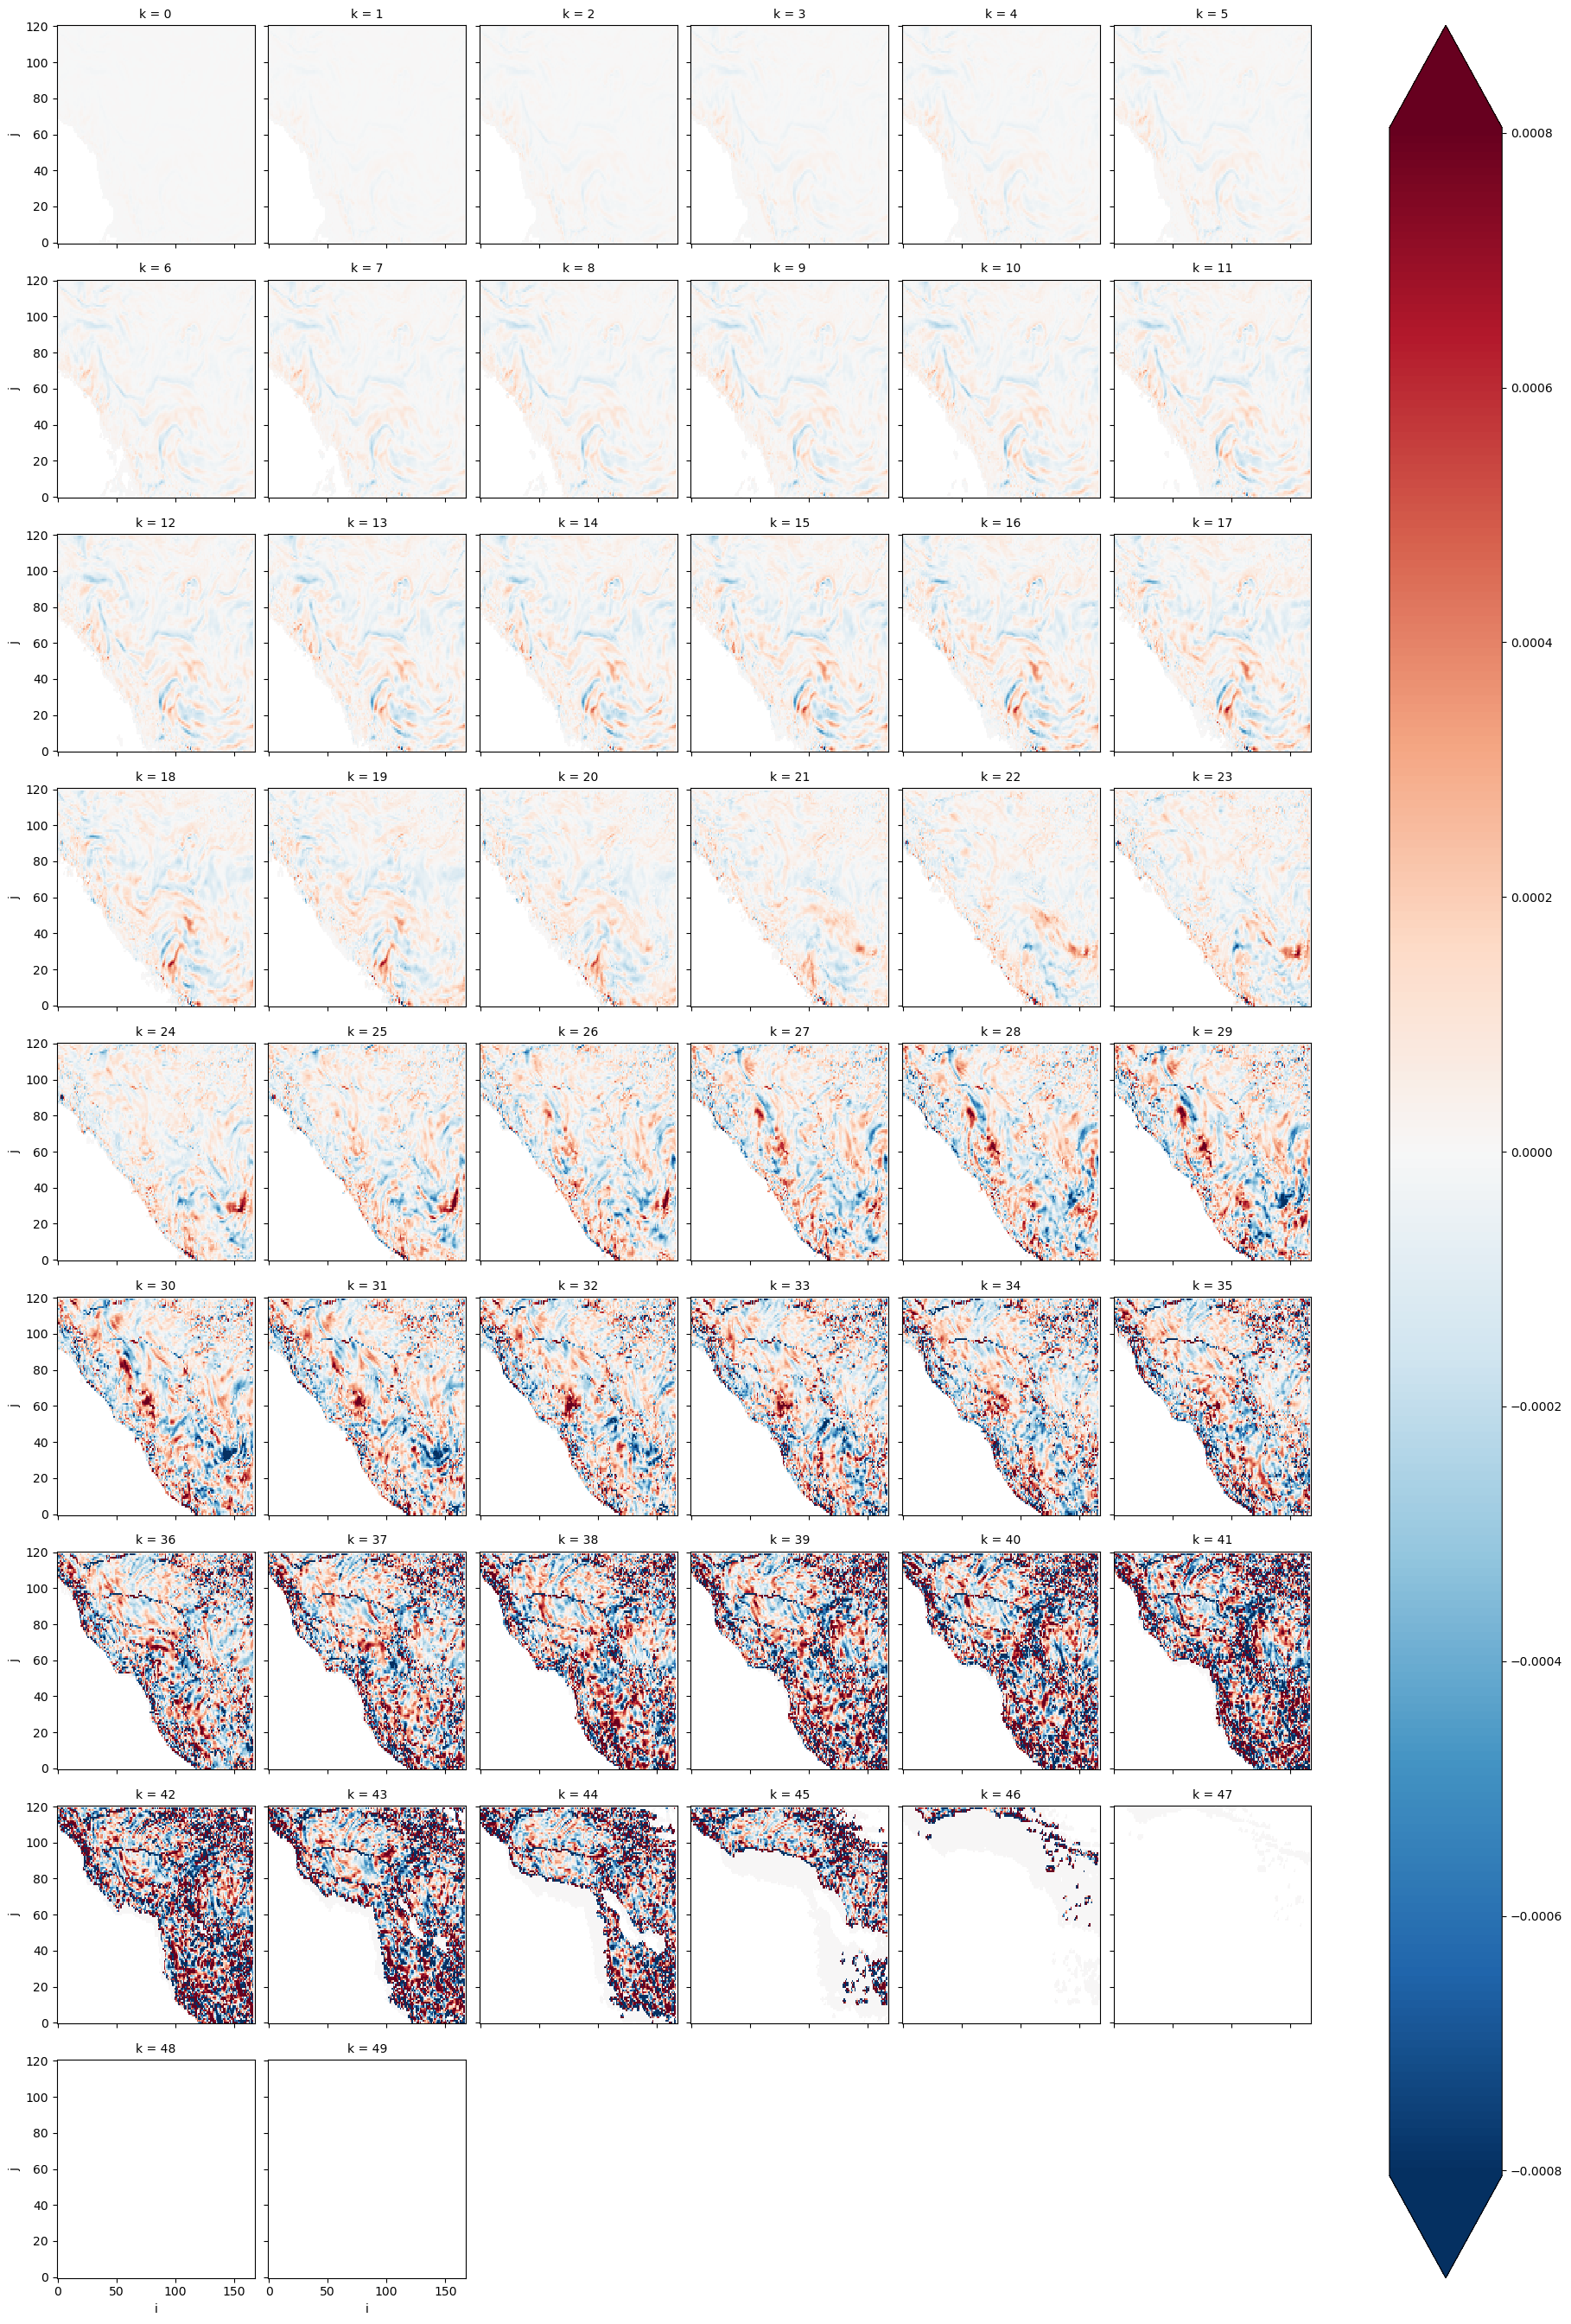

In [7]:
w_correct = w - w_bottom / ds.dz_t.where(ds.tmask==1).sum('k') * ds.depth_w
# w_correct.isel(j=100,i=100).plot(x='time',y='depth_t')
# plt.gca().invert_yaxis()
w_correct.isel(time=0).plot(x='i',y='j',col='k',col_wrap=6, robust=True)

In [8]:
# ## my version
# #we find the fluxes and add them : horizontal flux divergence = dF(u*dy*dz)/dx + dF(v*dx*dz)/dy -m2
# div = (
#     (ds.u.shift(i=-1)* ds.dy_t * ds.dz_t - ds.u * ds.dy_t * ds.dz_t)/ds.dx_t 
#     + (ds.v.shift(j=-1) * ds.dx_t * ds.dz_t - ds.v * ds.dx_t * ds.dz_t)/ds.dy_t
# ).fillna(0)

# #we multiply div * dz_t and integrate
# wk = (-div.fillna(0) * ds.dz_t.fillna(0)).cumsum('k').fillna(0).where(ds.tmask==1)
# wkk = wk/ds.dx_t/ds.dy_t

# w_bk=wkk.isel(k=ds.tmask.sum('k')-1)
# w_ck = wkk - w_bk / ds.dz_t.where(ds.tmask==1).sum('k') * ds.depth_w

Text(0.5, 1.0, 'Calculated W')

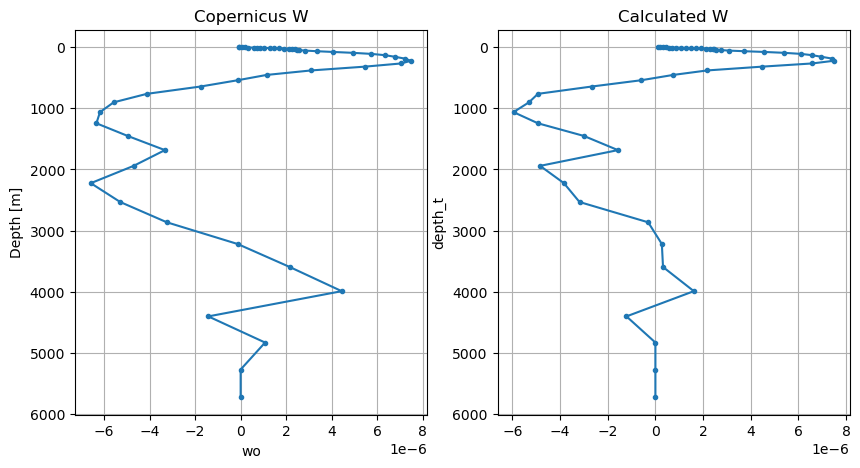

In [9]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

ds_w.wo.fillna(0).mean(dim=('longitude','latitude','time'),skipna=True).plot(y='depth',marker='.',ax=ax[0])
ax[0].invert_yaxis()
ax[0].grid()
ax[0].set_title('Copernicus W')

w_correct.fillna(0).mean(dim=('i','j','time'),skipna=True).plot(y='depth_t',marker='.',ax=ax[1])
ax[1].invert_yaxis()
ax[1].grid()
ax[1].set_title('Calculated W')

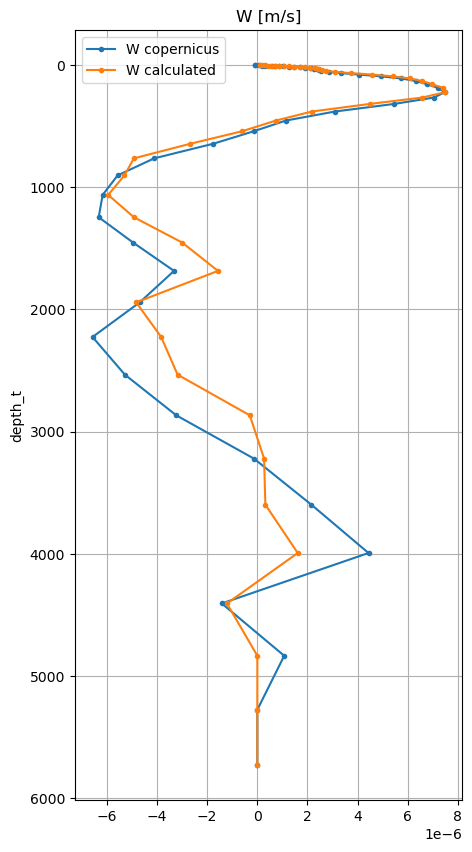

In [16]:
plt.subplots(figsize=(5,10))
ds_w.wo.fillna(0).mean(dim=('longitude','latitude','time'),skipna=True).plot(y='depth',marker='.',label='W copernicus')
w_correct.fillna(0).mean(dim=('i','j','time'),skipna=True).plot(y='depth_t',marker='.',label='W calculated')
# w.fillna(0).mean(dim=('i','j','time'),skipna=True).plot(y='depth_t',marker='.',label='W spurious')
# w_ck.fillna(0).mean(dim=('i','j','time'),skipna=True).plot(y='depth_t',marker='.',label='mine')

plt.gca().invert_yaxis()
plt.grid()
plt.title("W [m/s]")
plt.legend()

plt.savefig('Figures/W_compared.png',format='png', 
            dpi=300, transparent=False,bbox_inches='tight')

plt.show()